# SVGP — preview: mean + actual-coloured points, and \(\sigma\) (STD) surface

Mirrors `GPR/preview_diff_std.ipynb` for the SVGP residual model.  Loads the saved
`.pt` state (model + `scaler`/`qt`/`y_mean`/`y_std`); the surface machinery matches
`Plot_2D_residual_TP.ipynb`.

The SVGP target was QuantileTransformed, so the predictive std is propagated to
original units with a numerical Jacobian of the QT inverse:
\(\sigma_{\mathrm{orig}} = \sigma_{\mathrm{norm}}\, y_{\mathrm{std}}\,|\mathrm{d}\,\mathrm{QT}^{-1}/\mathrm{d}x|\).

Figures are also written to `PREVIEW_DIFF_STD/`.

In [1]:
import os
import numpy as np, pandas as pd
import torch, gpytorch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import thermoift.PLOT_SETTINGS as ps
from matplotlib.ticker import AutoMinorLocator
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.spatial import Delaunay
from scipy.interpolate import (interp1d, PchipInterpolator,
                               CloughTocher2DInterpolator, NearestNDInterpolator)
from sklearn.model_selection import train_test_split

In [2]:
OUTPUT_FOLDER = "SVGP_RESIDUAL_OUTPUTS"
MODEL_PATH    = os.path.join(OUTPUT_FOLDER, "SVGP_residual_model.pt")
PREVIEW       = "PREVIEW_DIFF_STD"
STD_CMAP      = "Blues"            # flipped: high sigma = dark
SIGMA_VMIN, SIGMA_VMAX = 0.0, 2.5  # shared sigma range (match make_shared_colorbar.py)
SEED          = 4555525

In [3]:
class SVGPModel(gpytorch.models.ApproximateGP):
    """Same architecture used during training."""
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True)
        super().__init__(variational_strategy)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=inducing_points.shape[1]))
    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x))

def predict_batched(model, likelihood, X_tensor, batch_size=2048):
    model.eval(); likelihood.eval()
    means, stds = [], []
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(X_tensor), batch_size):
            pred = likelihood(model(X_tensor[i:i + batch_size]))
            means.append(pred.mean.numpy()); stds.append(pred.stddev.numpy())
    return np.concatenate(means), np.concatenate(stds)

In [4]:
# ---- load saved state and rebuild the model ----------------------------------
state    = torch.load(MODEL_PATH, weights_only=False, map_location="cpu")
scaler   = state["scaler"]; qt = state["qt"]
y_mean   = state["y_mean"]; y_std = state["y_std"]
features = state["features"]; target = state["target"]; n_ind = state["n_inducing"]

svgp_model = SVGPModel(torch.zeros(n_ind, len(features), dtype=torch.float32))
svgp_model.load_state_dict(state["model_state_dict"])
likelihood = gpytorch.likelihoods.GaussianLikelihood()
likelihood.load_state_dict(state["likelihood_state_dict"])

# QT inverse + numerical Jacobian (matches SVGP_GPR_RESIDUAL.ipynb)
eps = 1e-4
def qt_inverse(arr):  return qt.inverse_transform(np.asarray(arr).reshape(-1, 1)).ravel()
def qt_jacobian(arr): return np.abs(qt_inverse(arr + eps) - qt_inverse(arr - eps)) / (2 * eps)

def predict_grid(Xdf):
    """Return (mean, std) in original mN/m units."""
    Xs = scaler.transform(np.asarray(Xdf, dtype=np.float32)).astype(np.float32)
    m_norm, s_norm = predict_batched(svgp_model, likelihood, torch.from_numpy(Xs))
    m_qt = m_norm * y_std + y_mean
    return qt_inverse(m_qt), s_norm * y_std * qt_jacobian(m_qt)

In [5]:
# ---- data + identical 70/15/15 split (Plot_2D_residual_TP cell 4) ------------
df = pd.read_csv("../CombinedDatasetSEC_A4.csv")
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df = df.dropna(subset=["gamma_wsd", "gamma_cDFT_minus_wsd_uncorrected", "gamma_wsd_UC"]).copy()
df["gamma_cDFT_UC"] = df["gamma_wsd_UC"] + df["gamma_cDFT_minus_wsd_uncorrected"]
df["residual"]      = df["gamma_cDFT_UC"] - df["gamma_wsd_UC"]

X, y = df[features], df[target]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test,  X_val,  y_test,  y_val  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)
T_tr, P_tr = X_train["T"].values, X_train["P"].values

# phase envelope
df_env_full = pd.read_csv("../../interfacial_results_dataset_A4.csv")
df_max = (df_env_full.groupby("temperature")[["P_bubble", "P_dew"]]
                     .max().reset_index().sort_values("temperature").dropna())
df_env = df_max.iloc[:-1].copy()
T_env, P_bub_env, P_dew_env = (df_env["temperature"].values,
                               df_env["P_bubble"].values, df_env["P_dew"].values)
bub = PchipInterpolator(T_env, P_bub_env, extrapolate=True)   # smooth, monotone (no kinks)
dew = PchipInterpolator(T_env, P_dew_env, extrapolate=True)

In [6]:
# ---- coarse grid + valid-domain mask; predict mean AND std -------------------
n_grid = 120
T_vals = np.linspace(T_tr.min(), T_tr.max(), n_grid)
P_vals = np.linspace(P_tr.min(), P_tr.max(), n_grid)
TT, PP = np.meshgrid(T_vals, P_vals)
hull   = Delaunay(np.column_stack([T_tr, P_tr]))
in_hull = hull.find_simplex(np.column_stack([TT.ravel(), PP.ravel()])) >= 0
in_env  = (PP.ravel() <= bub(TT.ravel())) & (PP.ravel() >= dew(TT.ravel()))
mask    = (in_hull & in_env).reshape(n_grid, n_grid)

T_idx, P_idx = features.index("T"), features.index("P")
X_grid = np.tile(X_train.median().values.copy(), (n_grid * n_grid, 1))
X_grid[:, T_idx] = TT.ravel(); X_grid[:, P_idx] = PP.ravel()

mean_flat, std_flat = predict_grid(pd.DataFrame(X_grid, columns=features))

/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [7]:
# ---- dense smooth grid + field builder ---------------------------------------
n_smooth = 500
T_s = np.linspace(T_tr.min(), T_tr.max(), n_smooth)
P_s = np.linspace(P_tr.min(), P_tr.max(), n_smooth)
TT_s, PP_s = np.meshgrid(T_s, P_s)
in_hull_s = hull.find_simplex(np.column_stack([TT_s.ravel(), PP_s.ravel()])) >= 0
in_env_s  = (PP_s.ravel() <= bub(TT_s.ravel())) & (PP_s.ravel() >= dew(TT_s.ravel()))
mask_s    = (in_hull_s & in_env_s).reshape(n_smooth, n_smooth)

def make_field(flat):
    g = flat.reshape(n_grid, n_grid).astype(float); g[~mask] = np.nan
    pts = np.column_stack([TT[~np.isnan(g)], PP[~np.isnan(g)]]); vals = g[~np.isnan(g)]
    ct, nn = CloughTocher2DInterpolator(pts, vals), NearestNDInterpolator(pts, vals)
    Z = ct(TT_s, PP_s); holes = np.isnan(Z); Z[holes] = nn(TT_s[holes], PP_s[holes])
    Zc = np.ma.masked_invalid(np.where(mask_s, Z, np.nan))
    return Z, Zc

Z_mean, Zc_mean = make_field(mean_flat)
Z_std,  Zc_std  = make_field(std_flat)

In [8]:
# ---- envelope clip polygon ---------------------------------------------------
clip_T = np.concatenate([T_s, T_s[::-1]])
clip_P = np.concatenate([bub(T_s), dew(T_s)[::-1]])
clip_path = Path(np.column_stack([clip_T, clip_P]), closed=True)

def _clip(artist, patch):
    try: artist.set_clip_path(patch)
    except AttributeError:
        for coll in getattr(artist, "collections", []): coll.set_clip_path(patch)

In [9]:
def render(Z, Zc, cmap, vmin, vmax, clabel, fname, ticks=None, extend="both",
           pts_vals=None, show_cbar=True):
    fig, ax = ps.plot_init(w=6, h=4.5)
    patch = PathPatch(clip_path, facecolor="none", edgecolor="none", transform=ax.transData)
    ax.add_patch(patch)
    pcm = ax.pcolormesh(TT_s, PP_s, Z, cmap=cmap, vmin=vmin, vmax=vmax,
                        shading="gouraud", zorder=1); _clip(pcm, patch)
    if pts_vals is not None:                       # points coloured by ACTUAL value, same scale
        sc = ax.scatter(T_tr, P_tr, c=pts_vals, cmap=cmap, vmin=vmin, vmax=vmax,
                        s=9, edgecolors="0.15", linewidths=0.3, zorder=5); _clip(sc, patch)
    cs = ax.contour(TT_s, PP_s, Zc, levels=np.linspace(vmin, vmax, 9),
                    colors="black", linewidths=0.9, zorder=6); _clip(cs, patch)
    cs.set_path_effects([pe.withStroke(linewidth=2.0, foreground="white")])  # halo: visible over points & dark bands
    lbls = ax.clabel(cs, inline=True, inline_spacing=3, fontsize=ps.label_fontsize * 0.65,
                     fmt=lambda v: f"${v:.2g}$")   # math mode -> LaTeX-rendered numbers
    plt.setp(lbls, path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    ax.plot(T_s, bub(T_s), "-", color="k", lw=ps.linewidth, zorder=7)
    ax.plot(T_s, dew(T_s), "-", color="k", lw=ps.linewidth, zorder=7)
    if show_cbar:
        cbar = fig.colorbar(pcm, ax=ax, pad=0.02, extend=extend)
        cbar.set_label(clabel, fontsize=ps.label_fontsize * 1.5)
        cbar.ax.tick_params(labelsize=ps.label_fontsize * 1.3); ps.style_colorbar(cbar)
        if ticks is not None: cbar.set_ticks(ticks)
    ax.set_xlabel(r"$T\ /\ [\mathrm{K}]$", fontsize=ps.label_fontsize * 1.5)
    ax.set_ylabel(r"$P\ /\ [\mathrm{bar}]$", fontsize=ps.label_fontsize * 1.5)
    ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=ps.label_fontsize)
    ax.xaxis.set_minor_locator(AutoMinorLocator()); ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_xlim(T_tr.min(), T_tr.max()); ax.set_ylim(P_tr.min(), P_tr.max())
    plt.tight_layout(); ps.save_plot(fig, fname, folder=PREVIEW); plt.show()

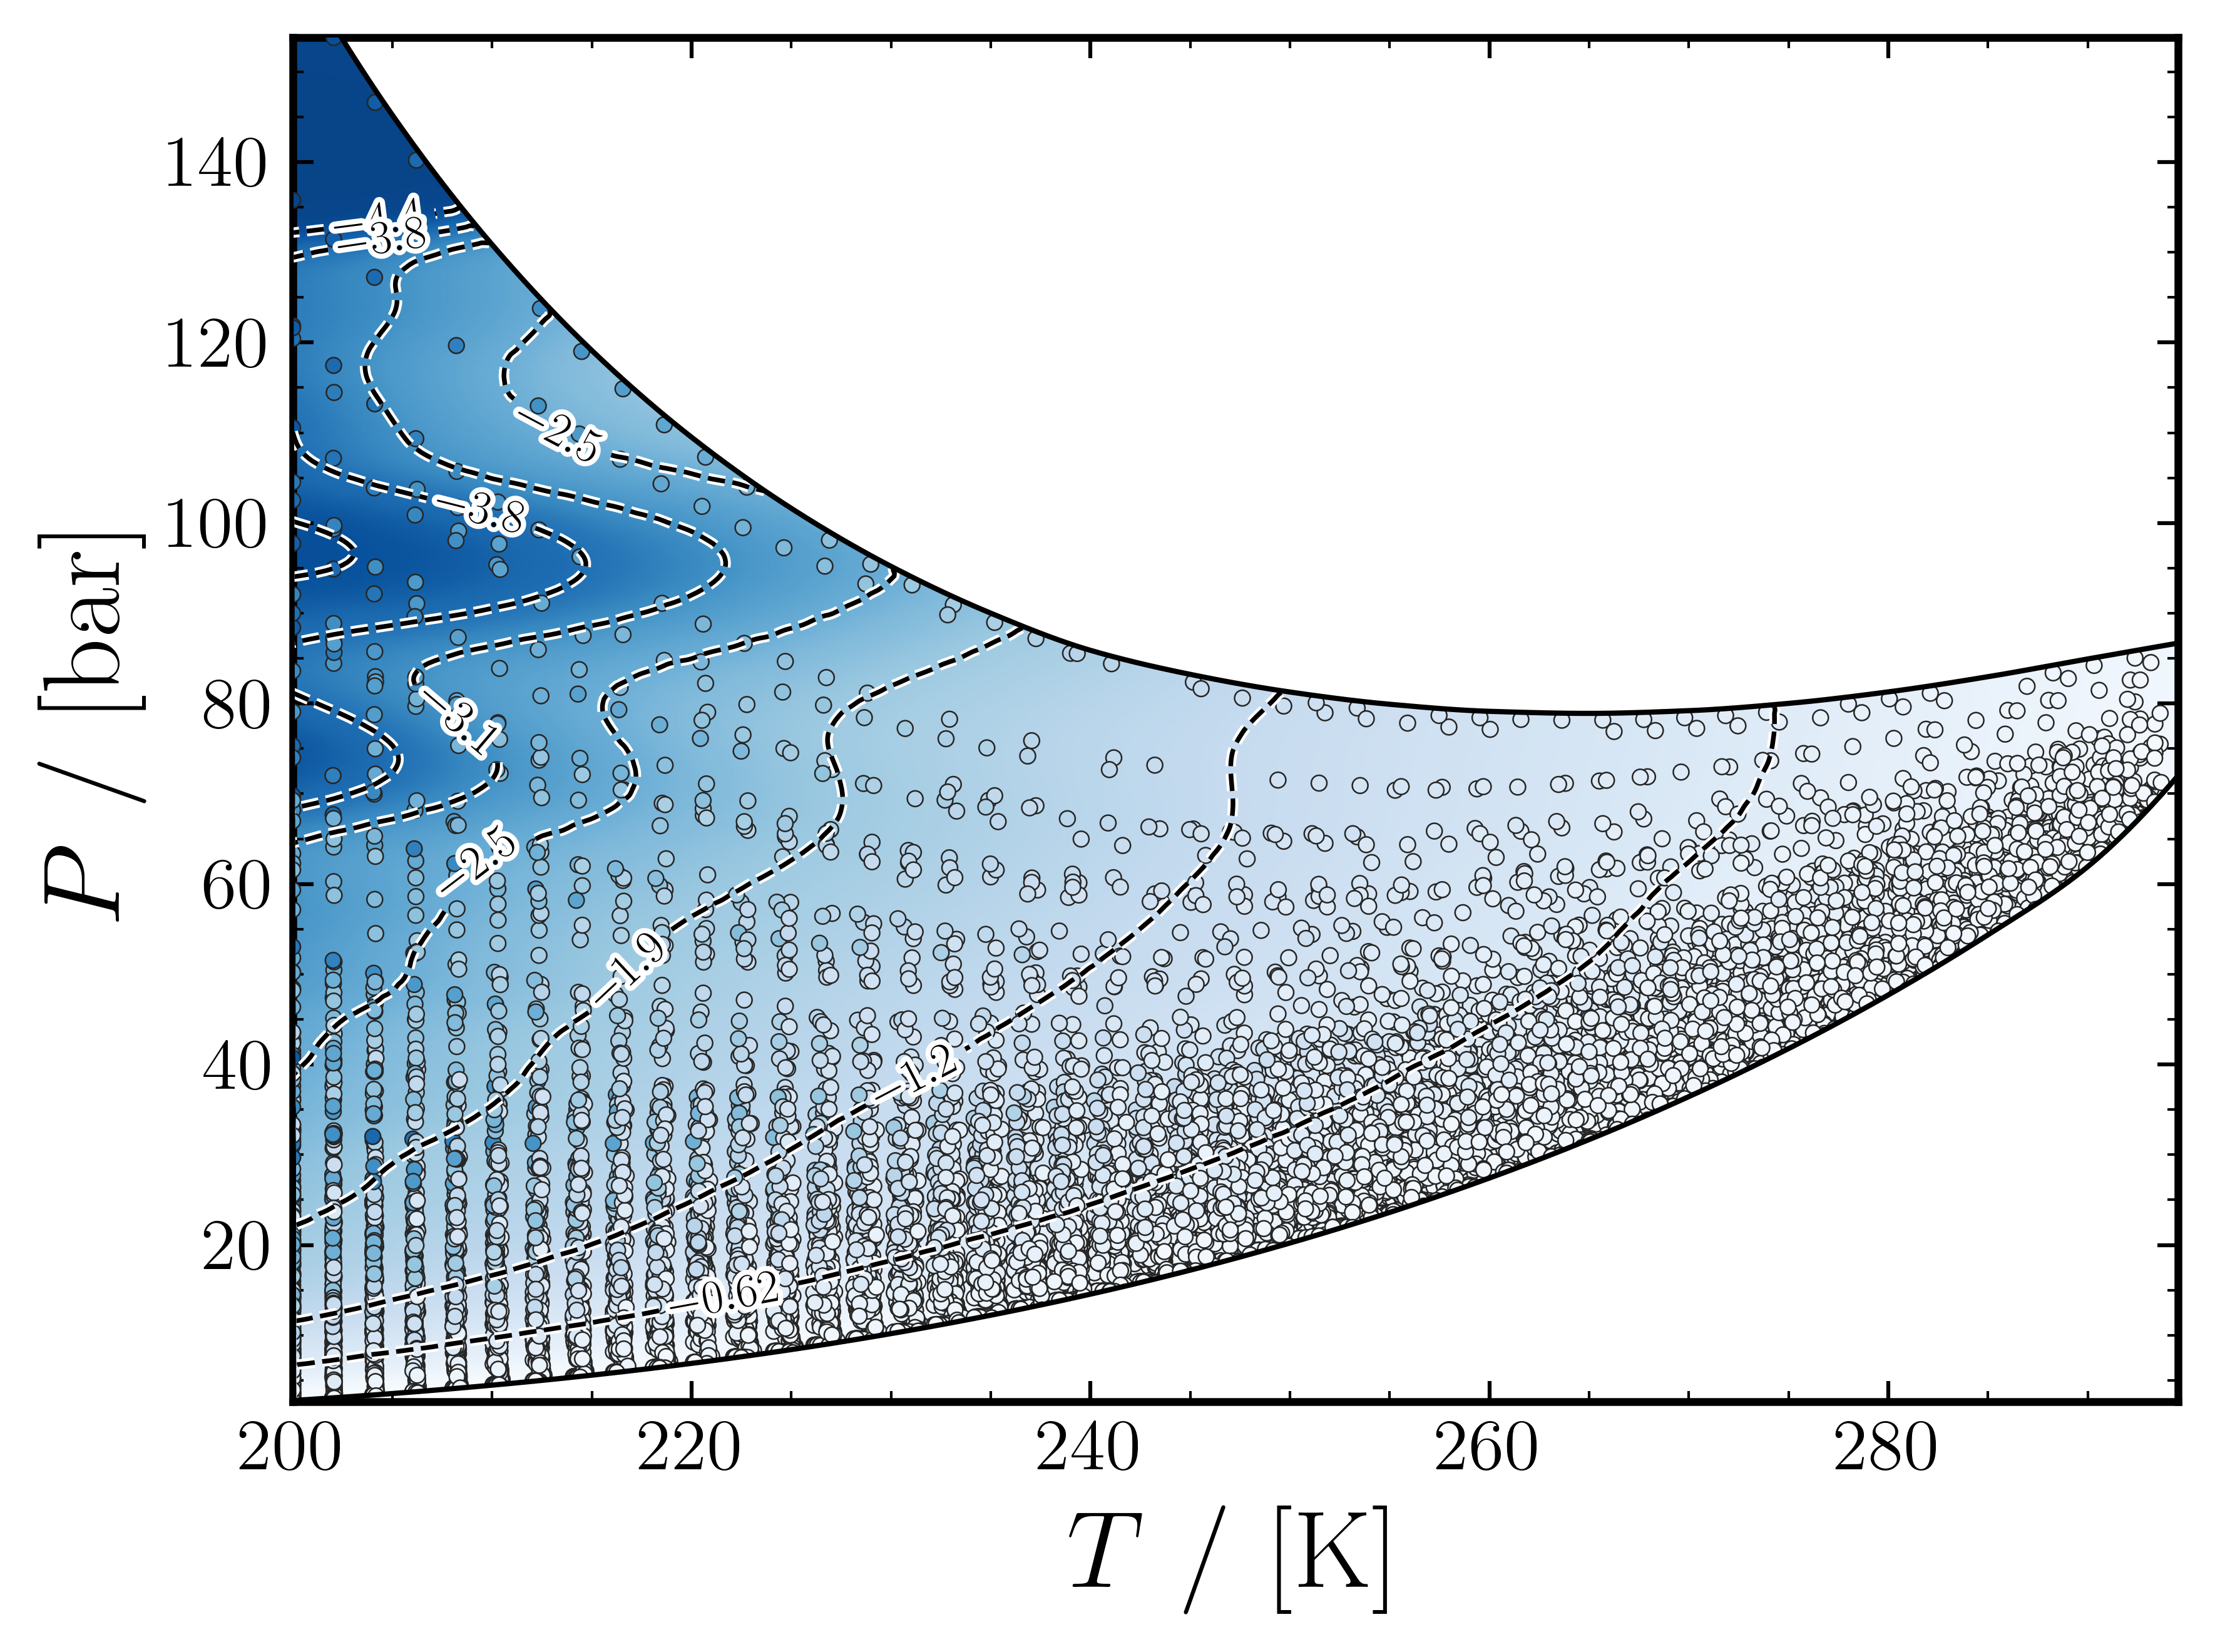

In [10]:
# (a) predicted-mean surface + training points coloured by ACTUAL Delta-gamma
render(Z_mean, Zc_mean, "Blues_r", -5.0, 0.0,
       r"$\langle\Delta\gamma\rangle\ /\ [\mathrm{mN}\,\mathrm{m}^{-1}]$",
       "Figure11c_SVGP_mean", ticks=[-4, -3, -2, -1], extend="both",
       pts_vals=y_train.values, show_cbar=False)

actual sigma range: [-0.006, 1.217]  (shared scale 0..2.5)


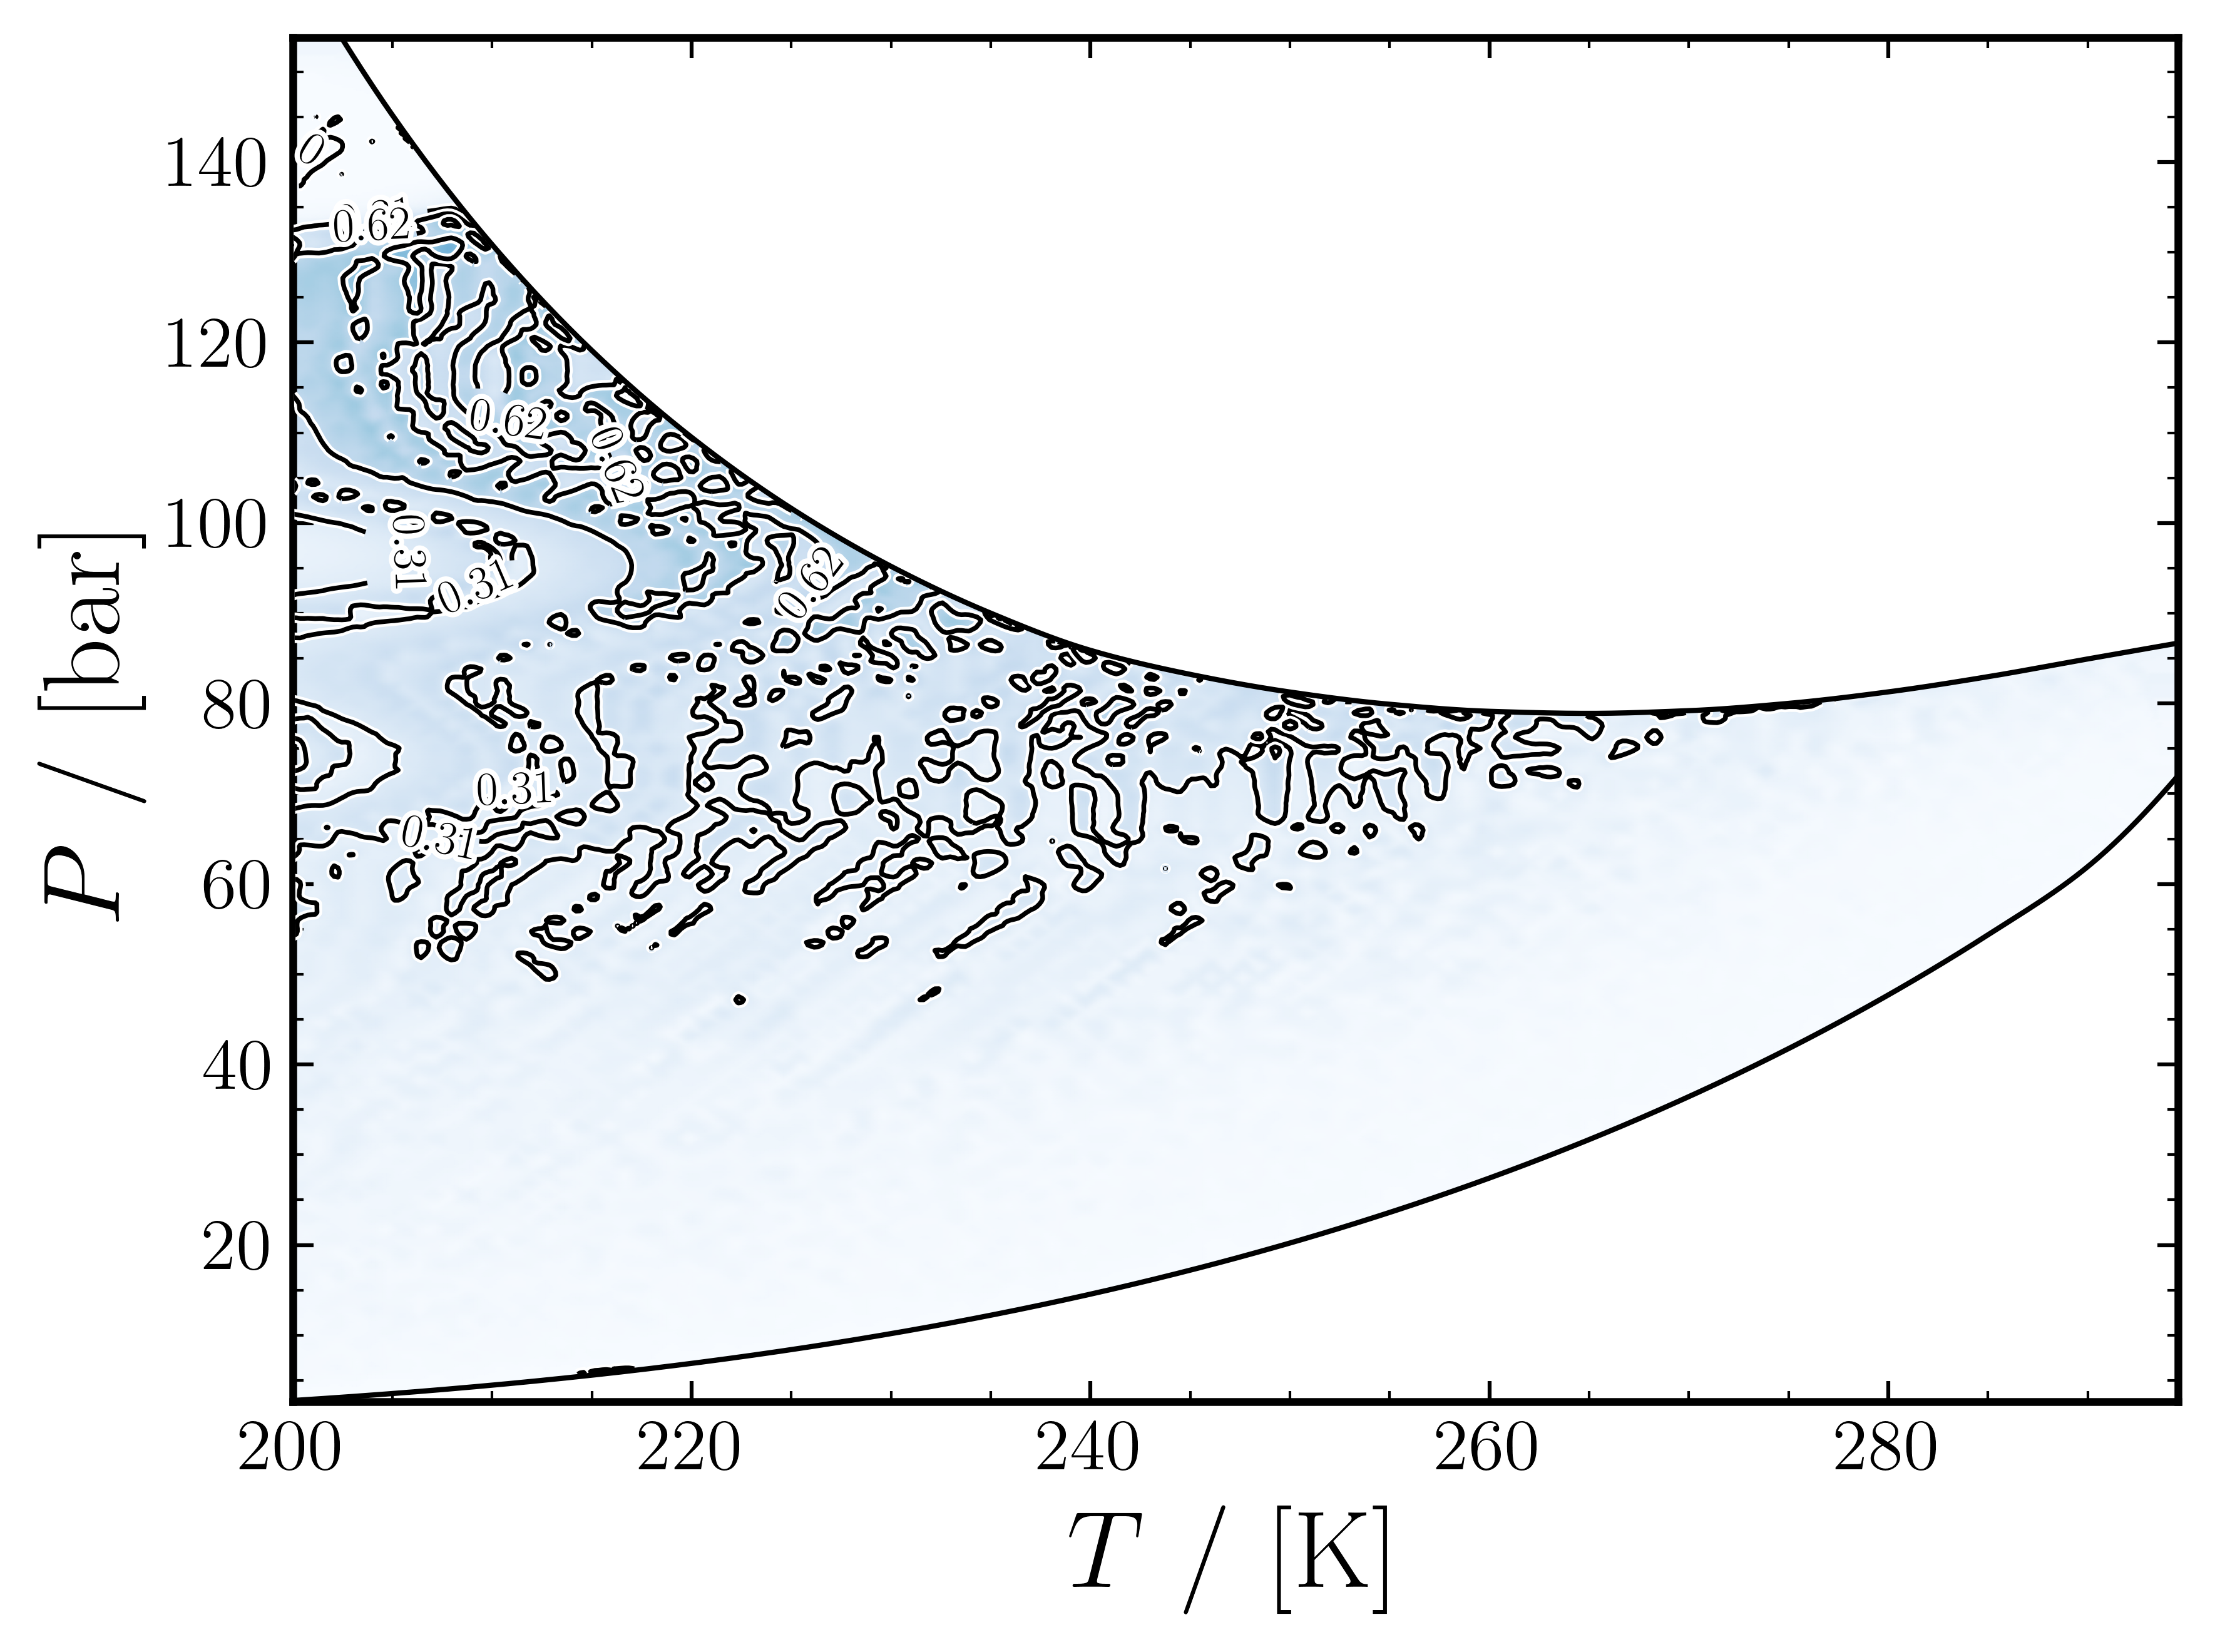

In [11]:
# (b) sigma (STD) surface — SHARED scale across GPR & SVGP (see SIGMA_VMAX)
svmin, svmax = float(np.nanmin(Zc_std)), float(np.nanmax(Zc_std))
print(f"actual sigma range: [{svmin:.3f}, {svmax:.3f}]  (shared scale 0..{SIGMA_VMAX})")
render(Z_std, Zc_std, STD_CMAP, SIGMA_VMIN, SIGMA_VMAX,
       r"$\sigma_{\Delta\gamma}\ /\ [\mathrm{mN}\,\mathrm{m}^{-1}]$",
       "Figure11d_SVGP_std", extend="max", show_cbar=False)